# CME/CBOT Corn Sep 2026 (ZCU26)

This notebook focuses on one real, tradable contract. It fetches the
historical OHLCV and open-interest data for ZCU26 from Barchart, draws
candlesticks, and adds causal streaming indicators from Screamer.

The chart uses only actual data for this named contract. It does not stitch
multiple contracts together, so ZCU26 remains the same contract throughout.

In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    (candidate for candidate in candidate_roots if (candidate / "Barchart").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this demo from a checkout containing the Barchart folder.")
sys.path.insert(0, str(repo_root))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import screamer
from IPython.display import display
from matplotlib.patches import Rectangle
from screamer import ATR, BollingerBands, RollingMean, RollingRSI

from Barchart import BarchartHistoricalData

CONTRACT = "ZCU26"
HISTORY_START = "2023-12-01"
PLOT_SESSIONS = 180

## 1. Fetch actual Barchart data

The client applies the final inclusive date bounds after decoding the
response, because the upstream endpoint can return extra rows.

In [2]:
client = BarchartHistoricalData()
history = client.history(
    CONTRACT,
    start_date=HISTORY_START,
    end_date=None,
    out="df",
)
if history.empty:
    raise ValueError(f"No Barchart rows returned for {CONTRACT}.")

history = history.sort_values("date").reset_index(drop=True)
required_columns = {"date", "open", "high", "low", "close", "volume"}
missing_columns = required_columns.difference(history.columns)
if missing_columns:
    raise ValueError(f"Barchart response is missing columns: {sorted(missing_columns)}")
if "openInterest" in history.columns:
    # Barchart can use zero as a missing-value sentinel for the latest row.
    history["openInterest"] = history["openInterest"].where(history["openInterest"] > 0)

close_values = history["close"].to_numpy(dtype=float)
high_values = history["high"].to_numpy(dtype=float)
low_values = history["low"].to_numpy(dtype=float)
volume_values = history["volume"].to_numpy(dtype=float)

bollinger = BollingerBands(window_size=20, num_std=2.0)(close_values)
history[["bb_lower", "bb_mid", "bb_upper"]] = bollinger
history["atr14"] = ATR(window_size=14)(
    high_values,
    low_values,
    close_values,
)
history["rsi14"] = RollingRSI(window_size=14)(close_values)
history["volume_mean20"] = RollingMean(window_size=20)(volume_values)
history["daily_change"] = history["close"].diff()
history["daily_return_pct"] = history["close"].pct_change() * 100

summary = pd.DataFrame(
    {
        "metric": [
            "Contract",
            "Contract month",
            "Indicator engine",
            "First trade date",
            "Last trade date",
            "Rows",
            "Last close (cents/bushel)",
            "Period low",
            "Period high",
            "Latest volume",
        ],
        "value": [
            CONTRACT,
            "September 2026",
            f"Screamer {screamer.__version__}",
            history["date"].min().date(),
            history["date"].max().date(),
            len(history),
            f"{history['close'].iat[-1]:.2f}",
            f"{history['low'].min():.2f}",
            f"{history['high'].max():.2f}",
            f"{int(history['volume'].iat[-1]):,}",
        ],
    }
)
display(summary)

,metric,value
0,Contract,ZCU26
1,Contract month,September 2026
2,Indicator engine,Screamer 2.5.0
3,First trade date,2023-12-14
4,Last trade date,2026-08-21
5,Rows,674
6,Last close (cents/bushel),483.75
7,Period low,406.25
8,Period high,511.25
9,Latest volume,"522,817"


## 2. Candlesticks with streaming indicators

The chart shows the latest 180 trading sessions for readability. The
indicators are calculated on the full history first, so their warm-up and
rolling state are not restarted at the chart boundary.

- Bollinger Bands: 20-session mean plus or minus two standard deviations.
- ATR: 14-session average true range, a price-volatility measure.
- RSI: 14-session relative strength index.
- Volume mean: 20-session rolling average of volume.

Non-positive open-interest values are treated as missing in the display
because Barchart can use zero as an unavailable-value sentinel.

C:\Users\etallent\AppData\Local\Temp\ipykernel_20200\2012877464.py:9: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  x_values = mdates.date2num(plot_data["date"].dt.to_pydatetime())


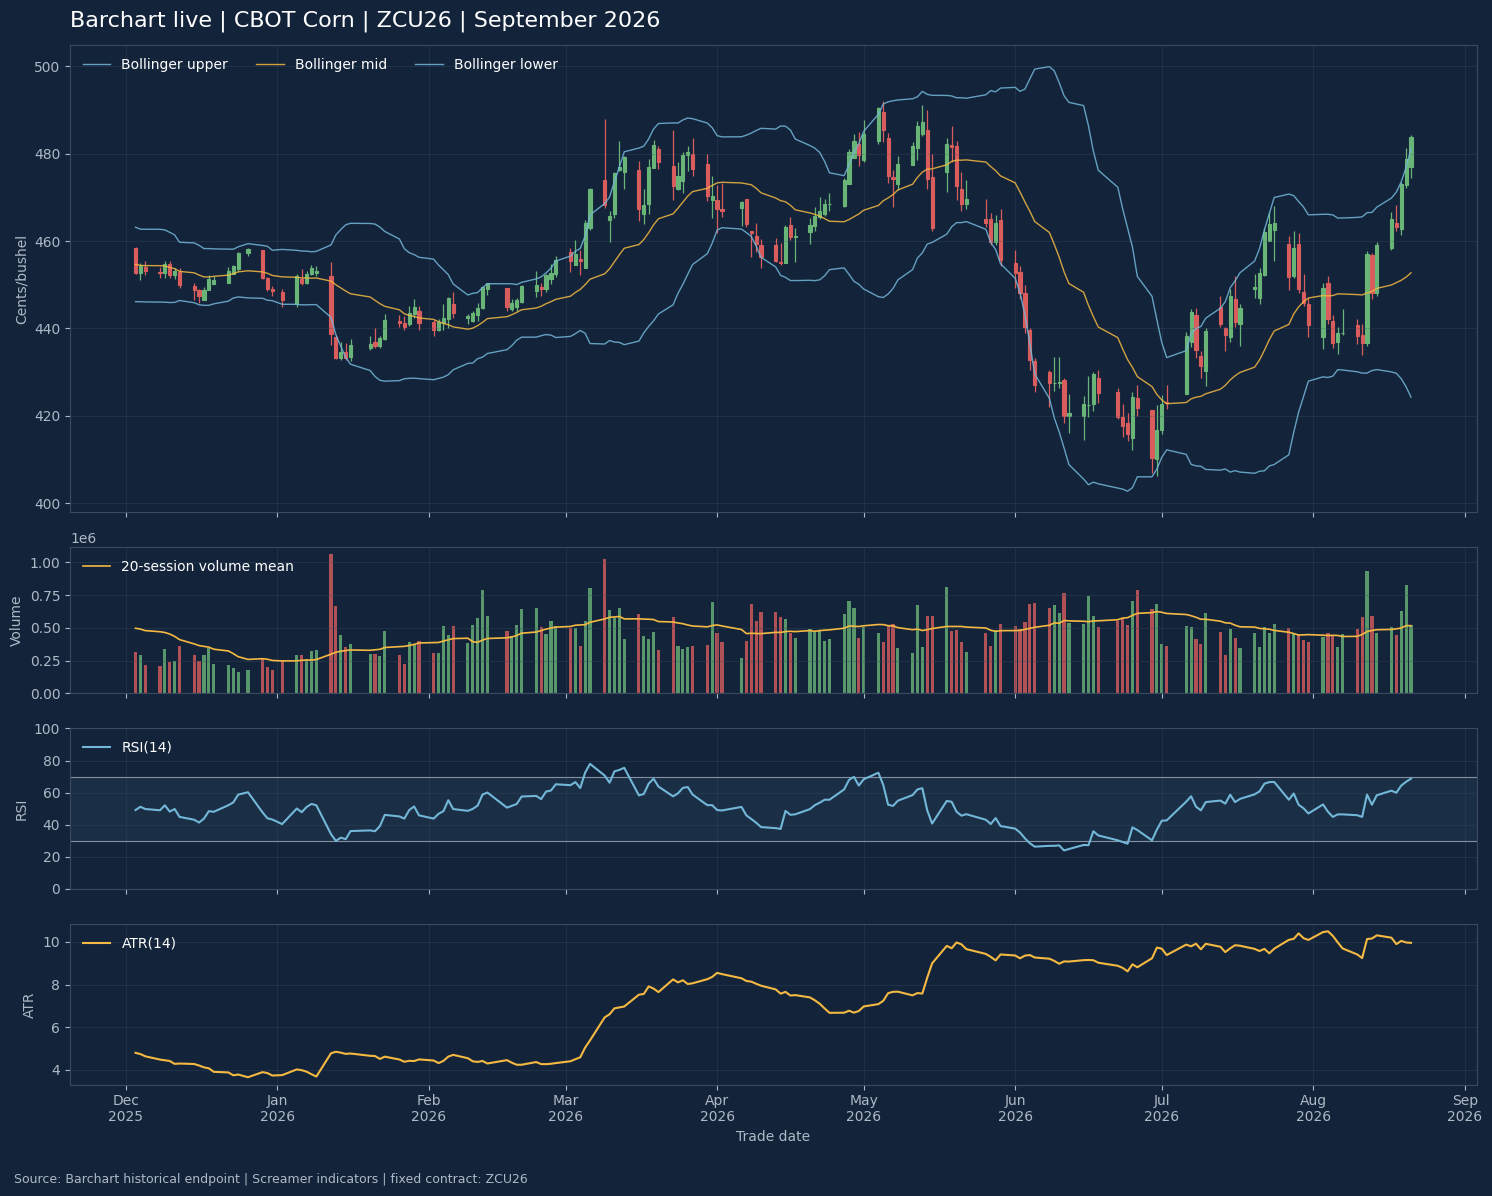

In [3]:
navy = "#13233A"
gold = "#F4B942"
field_green = "#69B578"
red = "#D95D5D"
sky = "#73B7D8"
muted = "#AEB9C6"

plot_data = history.tail(PLOT_SESSIONS).copy()
x_values = mdates.date2num(plot_data["date"].dt.to_pydatetime())
x_step = np.nanmedian(np.diff(x_values))
candle_width = max(float(x_step * 0.65), 0.25)

plt.style.use("dark_background")
fig, axes = plt.subplots(
    4,
    1,
    figsize=(15, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1, 1.1, 1.1]},
)
fig.patch.set_facecolor(navy)
for axis in axes:
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")

for x_value, (_, row) in zip(x_values, plot_data.iterrows()):
    bullish = row["close"] >= row["open"]
    color = field_green if bullish else red
    axes[0].vlines(x_value, row["low"], row["high"], color=color, linewidth=0.9)
    body_bottom = min(row["open"], row["close"])
    body_height = abs(row["close"] - row["open"])
    body_height = max(body_height, 0.01)
    axes[0].add_patch(
        Rectangle(
            (x_value - candle_width / 2, body_bottom),
            candle_width,
            body_height,
            facecolor=color,
            edgecolor=color,
            linewidth=0.8,
        )
    )

axes[0].plot(
    x_values,
    plot_data["bb_upper"],
    color=sky,
    linewidth=1.0,
    alpha=0.85,
    label="Bollinger upper",
)
axes[0].plot(
    x_values,
    plot_data["bb_mid"],
    color=gold,
    linewidth=1.0,
    alpha=0.85,
    label="Bollinger mid",
)
axes[0].plot(
    x_values,
    plot_data["bb_lower"],
    color=sky,
    linewidth=1.0,
    alpha=0.85,
    label="Bollinger lower",
)
axes[0].set_title(
    "Barchart live | CBOT Corn | ZCU26 | September 2026",
    loc="left",
    color="white",
    fontsize=16,
    pad=14,
)
axes[0].set_ylabel("Cents/bushel", color=muted)
axes[0].legend(frameon=False, labelcolor="white", loc="upper left", ncol=3)

bar_colors = np.where(
    plot_data["close"].to_numpy() >= plot_data["open"].to_numpy(),
    field_green,
    red,
)
axes[1].bar(
    x_values,
    plot_data["volume"],
    width=candle_width,
    color=bar_colors,
    alpha=0.8,
)
axes[1].plot(
    x_values,
    plot_data["volume_mean20"],
    color=gold,
    linewidth=1.2,
    label="20-session volume mean",
)
axes[1].set_ylabel("Volume", color=muted)
axes[1].legend(frameon=False, labelcolor="white", loc="upper left")

axes[2].axhspan(30, 70, color=sky, alpha=0.08)
axes[2].axhline(70, color=muted, linewidth=0.8, alpha=0.7)
axes[2].axhline(30, color=muted, linewidth=0.8, alpha=0.7)
axes[2].plot(
    x_values,
    plot_data["rsi14"],
    color=sky,
    linewidth=1.5,
    label="RSI(14)",
)
axes[2].set_ylim(0, 100)
axes[2].set_ylabel("RSI", color=muted)
axes[2].legend(frameon=False, labelcolor="white", loc="upper left")

axes[3].plot(
    x_values,
    plot_data["atr14"],
    color=gold,
    linewidth=1.5,
    label="ATR(14)",
)
axes[3].set_ylabel("ATR", color=muted)
axes[3].set_xlabel("Trade date", color=muted)
axes[3].legend(frameon=False, labelcolor="white", loc="upper left")

axes[3].xaxis_date()
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.text(
    0.01,
    0.01,
    "Source: Barchart historical endpoint | Screamer indicators | fixed contract: ZCU26",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 3. Recent observations

This table keeps the latest price move and activity visible without mixing
contracts or applying a roll rule.

In [4]:
recent_columns = [
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "daily_change",
    "daily_return_pct",
    "atr14",
    "rsi14",
]
if "openInterest" in history.columns:
    recent_columns.insert(6, "openInterest")

recent = history.tail(10)[recent_columns].copy()
recent["date"] = recent["date"].dt.strftime("%Y-%m-%d")
display(recent)

,date,open,high,low,close,volume,openInterest,daily_change,daily_return_pct,atr14,rsi14
664,2026-08-10,440.75,442.25,436.50,438.25,489062,1701378.0,-0.75,-0.170843,9.412977,45.948001
665,2026-08-11,438.50,441.00,434.00,436.75,580325,1684065.0,-1.50,-0.342270,9.240622,44.878449
666,2026-08-12,436.75,457.75,436.00,457.00,931069,1684252.0,20.25,4.636520,10.134149,58.815906
667,2026-08-13,456.75,457.25,446.75,448.00,591789,1695859.0,-9.00,-1.969365,10.160281,52.466327
668,2026-08-14,448.00,459.75,447.50,459.00,461322,1706223.0,11.00,2.455357,10.309547,58.380355
669,2026-08-17,458.50,466.75,458.00,465.00,503188,1721535.0,6.00,1.307190,10.198151,61.214941
670,2026-08-18,464.25,468.25,462.25,463.25,441553,1728003.0,-1.75,-0.376344,9.898283,59.932824
671,2026-08-19,462.75,473.50,461.50,473.00,627995,1723684.0,9.75,2.104695,10.048405,64.405837
672,2026-08-20,472.75,481.25,472.25,478.75,827984,1717199.0,5.75,1.215645,9.973519,66.762451
673,2026-08-21,477.00,484.25,474.50,483.75,522817,NaN,5.00,1.044386,9.957554,68.702892


## Notes

The [Barchart contract page](https://www.barchart.com/futures/quotes/ZCU26/overview)
identifies this instrument as Corn Sep '26 on the CBOT.

Screamer provides causal rolling indicators with the same API for historical
arrays and live streams. The package is used here for Bollinger Bands, ATR,
RSI, and rolling volume mean.

Running this notebook requires internet access and a working Barchart
session. The package does not store credentials.